# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Agrupación por cliente
- Modelo de recompra
- Explicabilidad
- Conclusiones del EDA

In [ ]:
%pip install openpyxl -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
DATA_PATH = 'online_retail_II.xlsx'

xl = pd.ExcelFile(DATA_PATH)
print(f'Hojas encontradas: {xl.sheet_names}')

df = pd.concat(
    [pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names],
    ignore_index=True
)

print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Hojas encontradas: ['Year 2009-2010', 'Year 2010-2011']
Filas: 1,067,371 | Columnas: 8


## 2. Primera inspección

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 3. Calidad de datos

In [7]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)

pd.DataFrame({
    'Nulos': nulos,
    '% del total': porcentaje_nulos
}).query('Nulos > 0')

,Nulos,% del total
Description,4382,0.41
Customer ID,243007,22.77


In [8]:
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados:,} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 34,335 (3.22%)


In [9]:
# Las facturas que empiezan por 'C' son cancelaciones
df['is_cancelled'] = df['Invoice'].astype(str).str.startswith('C')

n_cancelaciones = df['is_cancelled'].sum()
print(f'Transacciones canceladas: {n_cancelaciones:,} ({n_cancelaciones/len(df)*100:.2f}%)')
print(f'Transacciones normales:   {(~df["is_cancelled"]).sum():,}')

Transacciones canceladas: 19,494 (1.83%)
Transacciones normales:   1,047,877


In [10]:
print(f'Filas originales: {len(df):,}')

df_clean = df.drop_duplicates()
print(f'Tras quitar duplicados quedan: {len(df_clean):,}')

df_clean = df_clean[~df_clean['is_cancelled']].copy()
print(f'Tras quitar cancelaciones quedan: {len(df_clean):,}')

df_clean = df_clean.dropna(subset=['Customer ID'])
print(f'Tras quitar sin Customer ID quedan: {len(df_clean):,}')

df_clean = df_clean[df_clean['Price'] > 0].copy()
print(f'Tras quitar Price <= 0 quedan: {len(df_clean):,}')

df_clean = df_clean.drop(columns=['is_cancelled'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print(f'\n>>> Dataset limpio: {len(df_clean):,} filas ({len(df_clean)/len(df)*100:.1f}% del original)')

Filas originales: 1,067,371
Tras quitar duplicados quedan: 1,033,036
Tras quitar cancelaciones quedan: 1,013,932
Tras quitar sin Customer ID quedan: 779,495
Tras quitar Price <= 0 quedan: 779,425

>>> Dataset limpio: 779,425 filas (73.0% del original)


## 4. Estadísticas descriptivas

In [11]:
# Revenue = Quantity * Price
# Es el ingreso bruto por línea de transacción
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print('Distribución de variables numéricas\n')
display(df_clean[['Quantity', 'Price', 'Revenue']].describe())

print('\nDimensiones clave del negocio\n')
print(f"Clientes únicos:   {df_clean['Customer ID'].nunique():,}")
print(f"Facturas únicas:   {df_clean['Invoice'].nunique():,}")
print(f"Productos únicos:  {df_clean['StockCode'].nunique():,}")
print(f"Países:            {df_clean['Country'].nunique()}")
print(f"Rango temporal:    {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")
print(f"Facturación total: {df_clean['Revenue'].sum():,.2f} €")

print('\nEstadísticas agregadas por cliente\n')
customer_stats = df_clean.groupby('Customer ID').agg(
    n_compras    = ('Invoice', 'nunique'),
    total_gasto  = ('Revenue', 'sum'),
    ticket_medio = ('Revenue', 'mean'),
    items_total  = ('Quantity', 'sum')
)
display(customer_stats.describe())

print('\nTop 10 países por facturación\n')
display(df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10))

print('\nPercentiles extremos (detección de outliers)\n')
display(df_clean[['Quantity', 'Price', 'Revenue']].quantile([0.01, 0.05, 0.95, 0.99]))

Distribución de variables numéricas



,Quantity,Price,Revenue
count,779425.000000,779425.000000,779425.000000
mean,13.489370,3.218488,22.291823
std,145.855814,29.676140,227.427075
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.480000
75%,12.000000,3.750000,19.800000
max,80995.000000,10953.500000,168469.600000



Dimensiones clave del negocio

Clientes únicos:   5,878
Facturas únicas:   36,969
Productos únicos:  4,631
Países:            41
Rango temporal:    2009-12-01 07:45:00 → 2011-12-09 12:50:00
Facturación total: 17,374,804.27 €

Estadísticas agregadas por cliente



,n_compras,total_gasto,ticket_medio,items_total
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,6.289384,2955.904095,48.301822,1788.695475
std,13.009406,14440.852688,780.176769,8876.297196
min,1.000000,2.950000,2.135778,1.000000
25%,1.000000,342.280000,11.564180,187.000000
50%,3.000000,867.740000,17.367639,480.000000
75%,7.000000,2248.305000,24.181900,1350.000000
max,398.000000,580987.040000,56157.500000,367193.000000



Top 10 países por facturación



Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


Percentiles extremos (detección de outliers)



,Quantity,Price,Revenue
0.01,1.0,0.29,0.60
0.05,1.0,0.42,1.25
0.95,36.0,8.50,67.50
0.99,144.0,14.95,203.52


## 5. Visualizaciones

Cuatro bloques:
1. **Distribuciones** de Revenue, Quantity y Price
2. **Serie temporal** mensual de facturación y volumen
3. **Top países y productos** por facturación
4. **Patrones temporales**: día de semana y hora del día

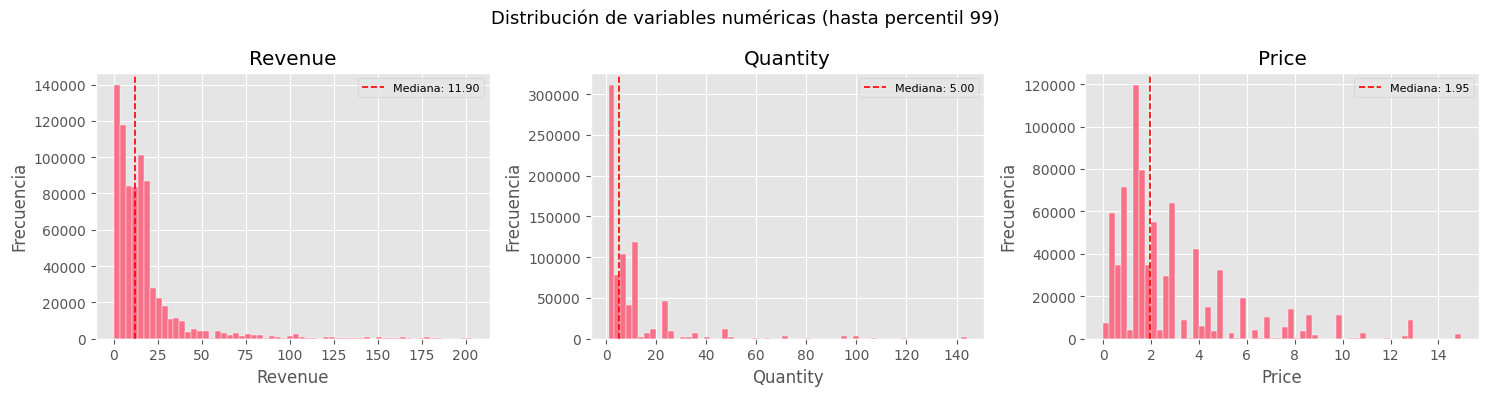

In [12]:
# ── 5.1 Distribuciones de variables numéricas ──────────────────────────────
# Cortamos en el percentil 99 para que los outliers extremos
# no compriman el histograma. Los valores reales siguen en el dataset.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de variables numéricas (hasta percentil 99)', fontsize=13)

for ax, col in zip(axes, ['Revenue', 'Quantity', 'Price']):
    cap = df_clean[col].quantile(0.99)
    data = df_clean[col][df_clean[col] <= cap]
    ax.hist(data, bins=60, edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

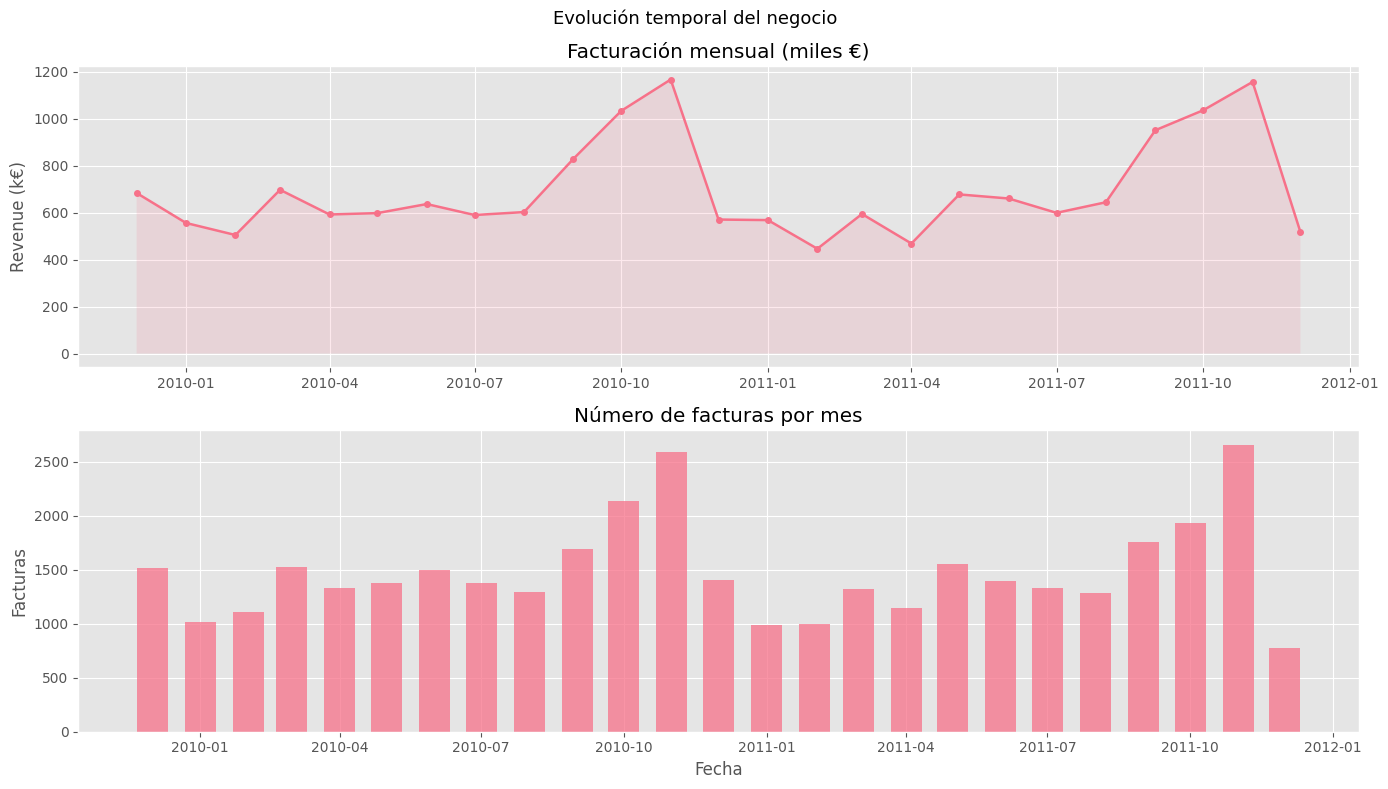

In [13]:
# ── 5.2 Serie temporal: facturación mensual ────────────────────────────────

df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_revenue = (
    df_clean.groupby('Month')['Revenue']
    .sum()
    .reset_index()
)
monthly_revenue['Month_dt'] = monthly_revenue['Month'].dt.to_timestamp()

monthly_invoices = (
    df_clean.groupby('Month')['Invoice']
    .nunique()
    .reset_index()
)
monthly_invoices['Month_dt'] = monthly_invoices['Month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Evolución temporal del negocio', fontsize=13)

axes[0].plot(monthly_revenue['Month_dt'], monthly_revenue['Revenue'] / 1e3,
             marker='o', markersize=4, linewidth=1.8)
axes[0].fill_between(monthly_revenue['Month_dt'], monthly_revenue['Revenue'] / 1e3, alpha=0.15)
axes[0].set_title('Facturación mensual (miles €)')
axes[0].set_ylabel('Revenue (k€)')

axes[1].bar(monthly_invoices['Month_dt'], monthly_invoices['Invoice'], width=20, alpha=0.75)
axes[1].set_title('Número de facturas por mes')
axes[1].set_ylabel('Facturas')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

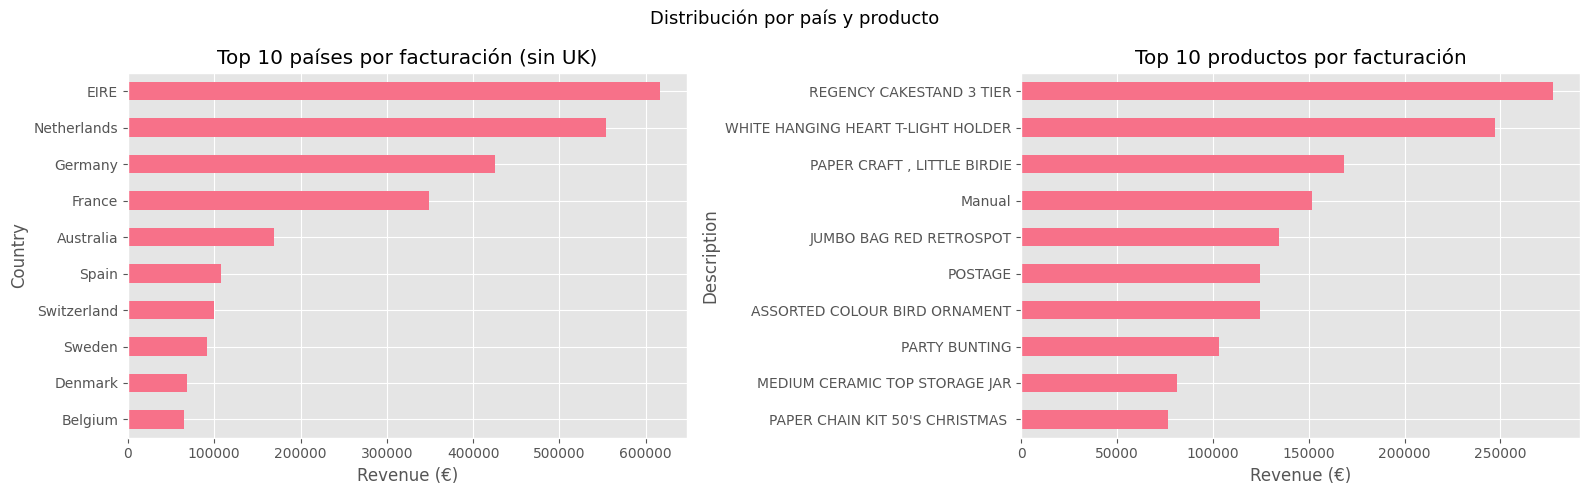

In [14]:
# ── 5.3 Top países y productos ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribución por país y producto', fontsize=13)

# Excluimos UK para ver el resto con claridad
top_countries = (
    df_clean[df_clean['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
top_countries.plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 10 países por facturación (sin UK)')
axes[0].set_xlabel('Revenue (€)')

top_products = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
top_products.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 productos por facturación')
axes[1].set_xlabel('Revenue (€)')

plt.tight_layout()
plt.show()

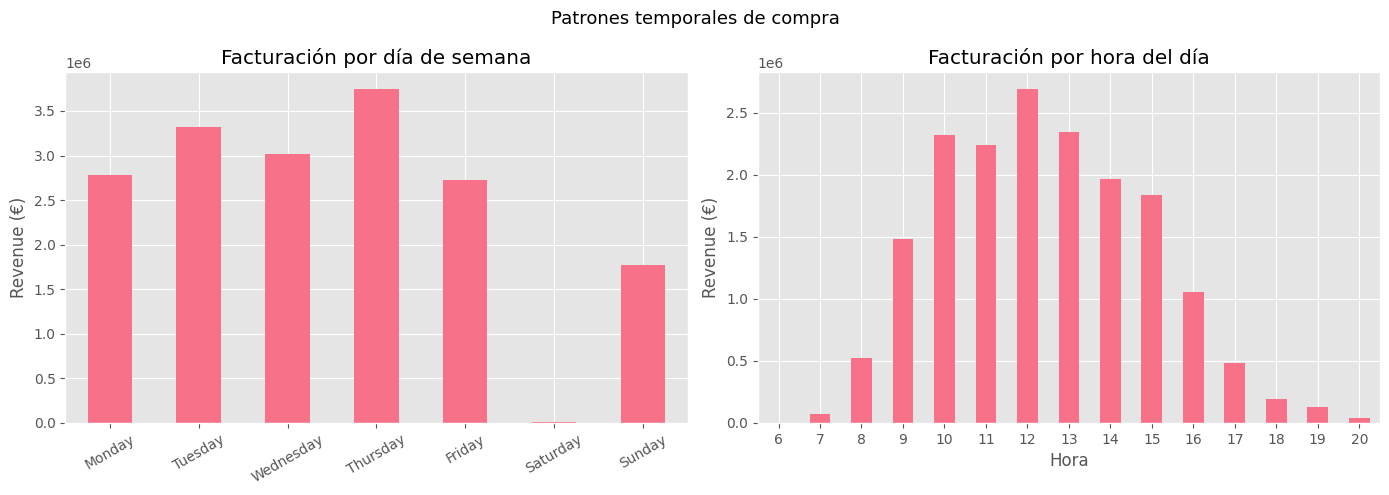

In [15]:
# ── 5.4 Patrones temporales: día de semana y hora ──────────────────────────

df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Patrones temporales de compra', fontsize=13)

day_rev = (
    df_clean.groupby('DayOfWeek')['Revenue']
    .sum()
    .reindex(day_order)
)
day_rev.plot(kind='bar', ax=axes[0], rot=30)
axes[0].set_title('Facturación por día de semana')
axes[0].set_ylabel('Revenue (€)')
axes[0].set_xlabel('')

hour_rev = df_clean.groupby('Hour')['Revenue'].sum()
hour_rev.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Facturación por hora del día')
axes[1].set_ylabel('Revenue (€)')
axes[1].set_xlabel('Hora')

plt.tight_layout()
plt.show()

## 6. Agrupación por cliente (Customer ID)

Construimos un dataset donde **cada fila es un cliente** con sus métricas históricas.
Este dataset es la base para el modelo de recompra.

Variables:
- `n_compras`: facturas distintas (frecuencia)
- `total_gasto`: suma de revenue (monetario)
- `ticket_medio`: gasto medio por factura
- `items_total`: unidades totales compradas
- `n_productos`: productos distintos comprados
- `recencia_dias`: días desde la última compra
- `antiguedad_dias`: días entre la primera y la última compra
- `pais_principal`: país con más compras del cliente

In [16]:
fecha_ref = df_clean['InvoiceDate'].max()

customer_df = df_clean.groupby('Customer ID').agg(
    n_compras      = ('Invoice',     'nunique'),
    total_gasto    = ('Revenue',     'sum'),
    items_total    = ('Quantity',    'sum'),
    n_productos    = ('StockCode',   'nunique'),
    ticket_medio   = ('Revenue',     'mean'),
    ultima_compra  = ('InvoiceDate', 'max'),
    primera_compra = ('InvoiceDate', 'min'),
    n_paises       = ('Country',     'nunique'),
    pais_principal = ('Country',     lambda x: x.mode()[0])
).reset_index()

customer_df['recencia_dias']  = (fecha_ref - customer_df['ultima_compra']).dt.days
customer_df['antiguedad_dias'] = (customer_df['ultima_compra'] - customer_df['primera_compra']).dt.days

customer_df = customer_df.drop(columns=['ultima_compra', 'primera_compra'])

print(f'Dataset agregado: {len(customer_df):,} clientes × {len(customer_df.columns)} variables')
display(customer_df.head())

Dataset agregado: 5,878 clientes × 10 variables


,Customer ID,n_compras,total_gasto,items_total,n_productos,ticket_medio,n_paises,pais_principal,recencia_dias,antiguedad_dias
0,12346,12,77556.46,74285,27,2281.072353,1,United Kingdom,325,400
1,12347,8,4921.53,2967,126,22.169054,1,Iceland,1,402
2,12348,5,2019.40,2714,25,39.596078,1,Finland,74,362
3,12349,4,4428.69,1624,138,25.306800,1,Italy,18,570
4,12350,1,334.40,197,17,19.670588,1,Norway,309,0


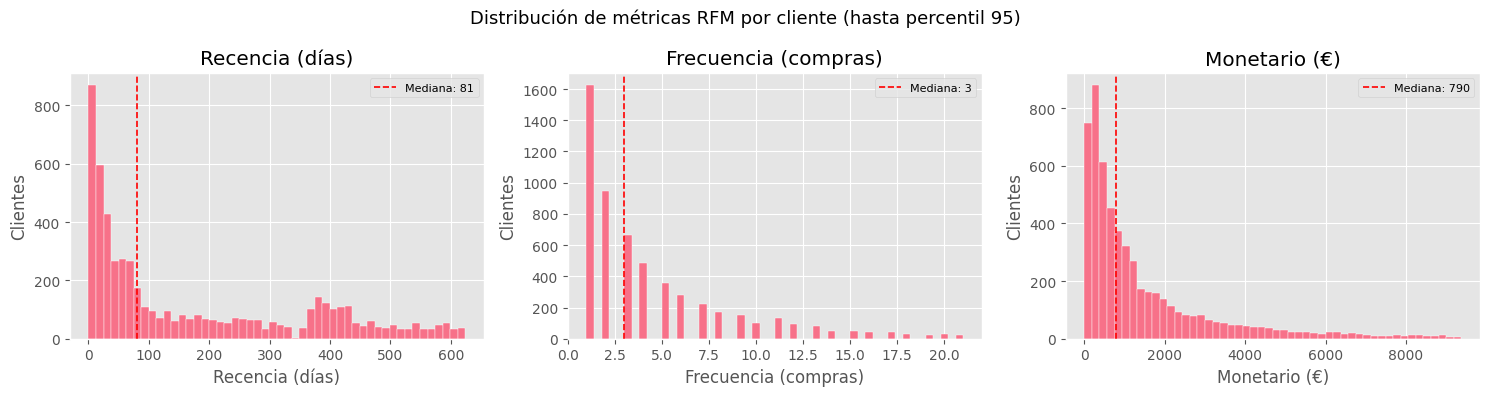

In [17]:
# Distribución de las métricas RFM principales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de métricas RFM por cliente (hasta percentil 95)', fontsize=13)

for ax, col, label in zip(
    axes,
    ['recencia_dias', 'n_compras', 'total_gasto'],
    ['Recencia (días)', 'Frecuencia (compras)', 'Monetario (€)']
):
    cap = customer_df[col].quantile(0.95)
    data = customer_df[col][customer_df[col] <= cap]
    ax.hist(data, bins=50, edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Clientes')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mediana: {data.median():.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Modelo: probabilidad de recompra

**Estrategia train/test con fecha de corte:**
- **Antes del corte** → features por cliente (RFM + otras)
- **Después del corte** → etiqueta: recompró (`1`) o no (`0`)
- Modelo: **regresión logística** con estandarización de features

Fecha de corte elegida para dejar ~3 meses de ventana de observación.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)

# ── 7.1 Fecha de corte ─────────────────────────────────────────────────────
cutoff_date = pd.Timestamp('2011-09-01')
print(f'Fecha de corte: {cutoff_date.date()}')
print(f'Periodo features: {df_clean["InvoiceDate"].min().date()} → {cutoff_date.date()}')
print(f'Periodo etiquetas: {cutoff_date.date()} → {df_clean["InvoiceDate"].max().date()}')

Fecha de corte: 2011-09-01
Periodo features: 2009-12-01 → 2011-09-01
Periodo etiquetas: 2011-09-01 → 2011-12-09


In [19]:
# ── 7.2 Features (datos antes corte) ──────────────────────────────────

df_before = df_clean[df_clean['InvoiceDate'] < cutoff_date].copy()

features_df = df_before.groupby('Customer ID').agg(
    n_compras      = ('Invoice',     'nunique'),
    total_gasto    = ('Revenue',     'sum'),
    items_total    = ('Quantity',    'sum'),
    n_productos    = ('StockCode',   'nunique'),
    ticket_medio   = ('Revenue',     'mean'),
    ultima_compra  = ('InvoiceDate', 'max'),
    pais_principal = ('Country',     lambda x: x.mode()[0])
).reset_index()

features_df['recencia_dias'] = (cutoff_date - features_df['ultima_compra']).dt.days
features_df = features_df.drop(columns=['ultima_compra'])


features_df['es_uk'] = (features_df['pais_principal'] == 'United Kingdom').astype(int)
features_df = features_df.drop(columns=['pais_principal'])

print(f'Clientes con actividad antes del corte: {len(features_df):,}')

Clientes con actividad antes del corte: 5,249


In [20]:
# ── 7.3 Etiquetas (datos DESPUÉS del corte) ────────────────────────────────
# target = 1 si el cliente hizo al menos una compra después del corte

df_after = df_clean[df_clean['InvoiceDate'] >= cutoff_date]
recompradores = set(df_after['Customer ID'].unique())

features_df['target'] = features_df['Customer ID'].isin(recompradores).astype(int)

tasa = features_df['target'].mean()
print(f'Recompraron: {features_df["target"].sum():,} ({tasa:.1%})')
print(f'No recompraron: {(features_df["target"]==0).sum():,} ({1-tasa:.1%})')

Recompraron: 2,344 (44.7%)
No recompraron: 2,905 (55.3%)


In [21]:
# ── 7.4 Train/test split y modelo ─────────────────────────────────────────

FEATURE_COLS = ['n_compras', 'total_gasto', 'items_total',
                'n_productos', 'ticket_medio', 'recencia_dias', 'es_uk']

X = features_df[FEATURE_COLS]
y = features_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline: estandarizar + regresión logística
# class_weight='balanced' compensa el desbalance de clases
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Validación cruzada antes de entrenar en todo el train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_cv = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'ROC-AUC CV (5 folds): {auc_cv.mean():.3f} ± {auc_cv.std():.3f}')

# Entrenamos y evaluamos en test
pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(f'\nROC-AUC en test: {roc_auc_score(y_test, y_proba):.3f}')
print()
print(classification_report(y_test, y_pred))

ROC-AUC CV (5 folds): 0.798 ± 0.014

ROC-AUC en test: 0.787

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       581
           1       0.67      0.71      0.69       469

    accuracy                           0.71      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.71      0.71      0.71      1050



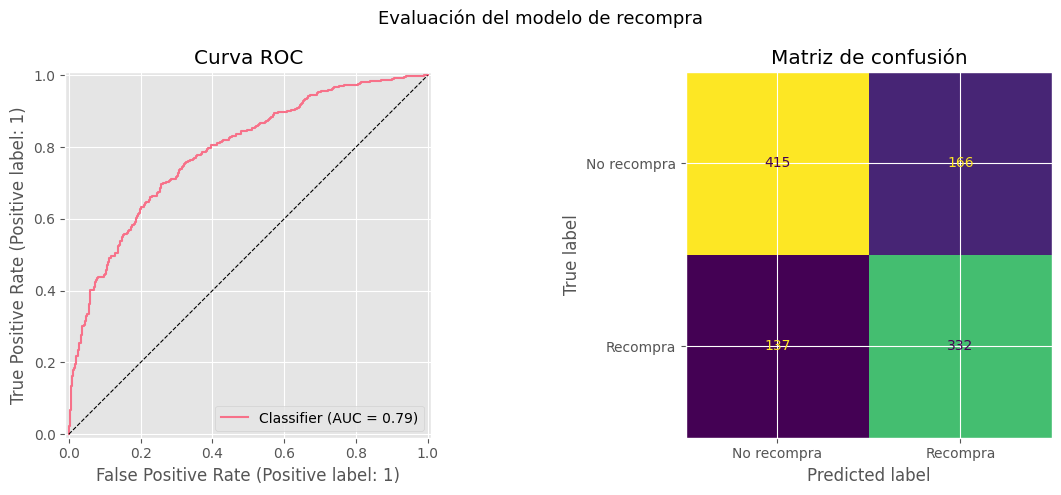

In [22]:
# ── 7.5 Curva ROC + Matriz de confusión ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Evaluación del modelo de recompra', fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('Curva ROC')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['No recompra', 'Recompra']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

### (Opcional) Búsqueda de hiperparámetros

In [23]:
# ── (Opcional) GridSearch sobre C (regularización) ────────────────────────
# Descomenta para ejecutar. Puede tardar 1-2 minutos.

# from sklearn.model_selection import GridSearchCV

# param_grid = {'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}
# gs = GridSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
# gs.fit(X_train, y_train)

# print(f'Mejor C: {gs.best_params_}')
# print(f'Mejor AUC CV: {gs.best_score_:.3f}')

## 8. Modelo: explicabilidad

Para regresión logística la explicabilidad es directa:
- Los **coeficientes** indican el efecto de cada variable sobre el log-odds de recompra
- Son comparables entre sí porque las features están estandarizadas
- **Coeficiente positivo** → mayor valor = más probable la recompra
- El **Odds Ratio** = e^coeficiente indica el multiplicador del riesgo por cada desviación estándar de aumento

,Feature,Coeficiente,Odds Ratio
0,n_compras,0.829393,2.292
3,n_productos,0.431720,1.540
1,total_gasto,0.236592,1.267
2,items_total,0.008322,1.008
6,es_uk,-0.035846,0.965
4,ticket_medio,-0.322195,0.725
5,recencia_dias,-0.807628,0.446


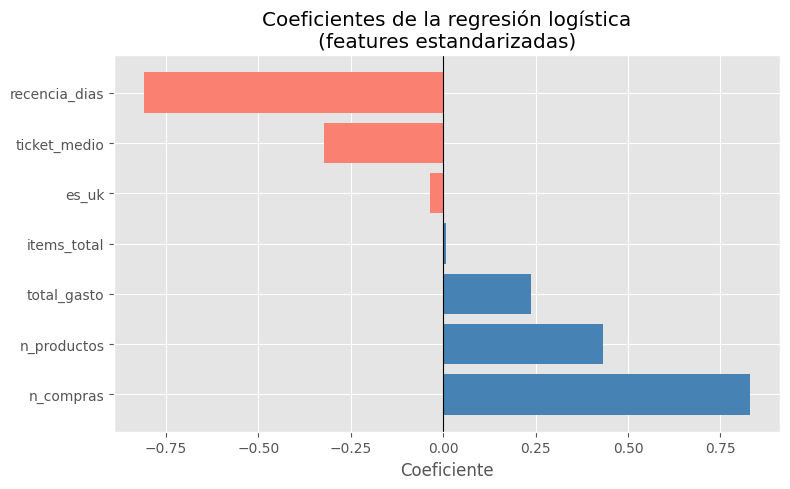

In [24]:
# ── 8.1 Coeficientes del modelo ────────────────────────────────────────────

coef_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coeficiente': pipeline.named_steps['model'].coef_[0]
}).sort_values('Coeficiente', ascending=False)

coef_df['Odds Ratio'] = np.exp(coef_df['Coeficiente']).round(3)

display(coef_df)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes de la regresión logística\n(features estandarizadas)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

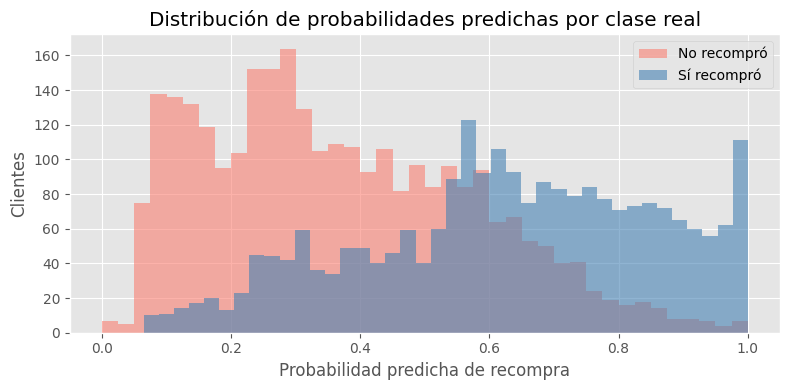

In [25]:
# ── 8.2 Distribución de probabilidades predichas por clase ─────────────────
# Un buen modelo separa bien las distribuciones de las dos clases

features_df['prob_recompra'] = pipeline.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features_df[features_df['target']==0]['prob_recompra'],
        bins=40, alpha=0.6, label='No recompró', color='salmon')
ax.hist(features_df[features_df['target']==1]['prob_recompra'],
        bins=40, alpha=0.6, label='Sí recompró', color='steelblue')
ax.set_xlabel('Probabilidad predicha de recompra')
ax.set_ylabel('Clientes')
ax.set_title('Distribución de probabilidades predichas por clase real')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 8.3 (Opcional) SHAP para explicabilidad avanzada ─────────────────────
# SHAP muestra el impacto de cada feature en cada predicción individual.
# pip install shap

# import shap
# X_scaled = pipeline.named_steps['scaler'].transform(X)
# explainer = shap.LinearExplainer(
#     pipeline.named_steps['model'], X_scaled, feature_names=FEATURE_COLS
# )
# shap_values = explainer(X_scaled)
# shap.plots.bar(shap_values)       # importancia global
# shap.plots.beeswarm(shap_values)  # distribución de impactos por feature

: 

## 9. Conclusiones del EDA

**Calidad de datos:**
- Dataset original: 1.07M filas → tras limpieza: 779k filas (73% del original).
- El 22.8% de transacciones no tiene Customer ID (no atribuibles a ningún cliente).

**Negocio:**
- 5,878 clientes únicos en 41 países. UK representa ~83% de la facturación total.
- Pico de ventas claro en octubre-noviembre (campaña de Navidad).
- Operación en horario de oficina (9h-17h), sin actividad nocturna ni fin de semana → perfil B2B.

**Modelo de recompra:**
- `recencia_dias` y `n_compras` son los predictores más potentes.
- Clientes con compras recientes y frecuentes tienen alta probabilidad de volver.
- La regresión logística es un buen baseline interpretable. Para mejorar el AUC se puede probar XGBoost o LightGBM.